# AI Race Game Theory

A game-theoretic model of AI safety race dynamics between competing labs and nations.

**Calibration:** All results use α≈0.466, k≈33.9, calibrated so that 1% safety spending → 80% alignment probability, 50% spending → 98% alignment.

In [1]:
%matplotlib inline
from report import full_model, interventions, plots_v2, sensitivity, toy_model

## 1. Toy Model

Consider $n$ identical actors, each splitting resources between safety ($s$) and capabilities ($c = 1-s$). Alignment probability is $P(s) = \frac{ks^\alpha}{ks^\alpha + c}$. If any AI is misaligned, all payoffs are zero. Otherwise, payoffs are split proportional to $c^w$.

### Closed form ($\alpha = 1$)

With $\alpha = 1$ and winner-take-all exponent $w$, the symmetric Nash equilibrium alignment probability $p^*$ solves a quadratic:

$$n(k-1)p^2 - [n(2k-1) + w(n-1)]p + nk = 0$$

For large $k$: $p \approx 1 - \sqrt{\frac{w(n-1)}{nk}}$, giving joint survival $\approx 1 - \sqrt{\frac{nw(n-1)}{k}}$.

Note that misalignment probability only *decreases* with $k$ — it never reaches zero because actors always trade some safety for competitive advantage. Even at $k=100$, the equilibrium misalignment probability is about 10% per actor.

With general $w$, winner-take-all dynamics intensify racing: the $\sqrt{w}$ factor in the asymptotic formula shows that doubling $w$ increases misalignment risk by $\sqrt{2} \approx 41\%$.

For $\alpha \neq 1$ (our calibrated value α=0.466), no closed form exists, but the qualitative behavior is similar with diminishing returns making small safety investments more effective.

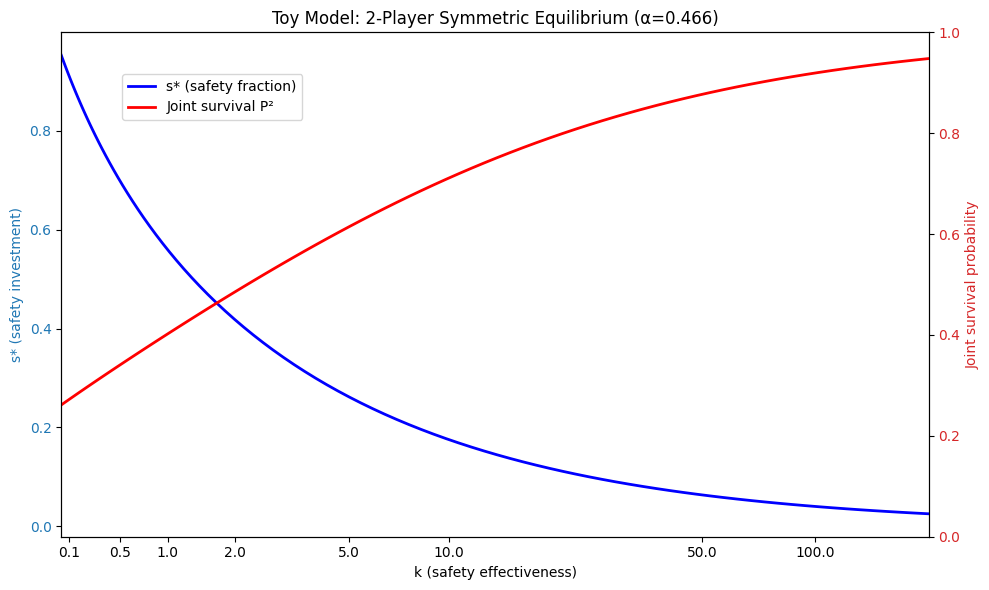

In [2]:
data = toy_model.toy_baseline_vs_k()
plots_v2.plot_toy_baseline(data);

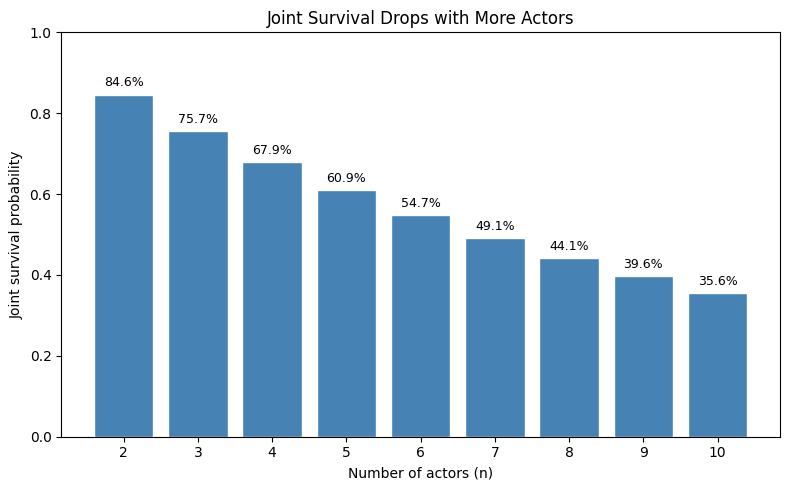

In [3]:
data = toy_model.toy_n_actors()
plots_v2.plot_toy_n_actors(data);

Joint survival drops sharply with more actors because survival requires *all* AIs to be aligned. Individual safety spending doesn't change much, but the compound probability $P^n$ falls rapidly.

## 2. Full Model

The full model extends the toy model with:
- **5 labs**: OAI, Anthropic, GDM, xAI, China with asymmetric resources $R$
- **Amity matrix $A$**: How much each lab values others' aligned ASI
- **Winner-take-all $w=2$**: Quadratic capability returns
- **Public good $\delta=0.5$**: Partial safety spillovers
- **Correlation $\rho=0.5$**: Alignment outcomes partially correlated
- **Misaligned power $z=1$**: Misaligned AI has maximal power advantage

The key output metric is **expected human share** — the expected fraction of the universe controlled by aligned AI. This can be interpreted as survival probability in a unipolar world, or humanity's share of resources in a multipolar post-ASI future.

### Default Parameters

| Lab | Resources $R_i$ |
|-----|----------------|
| GDM | 0.30 |
| OAI | 0.25 |
| Anthropic | 0.15 |
| xAI | 0.15 |
| China | 0.15 |

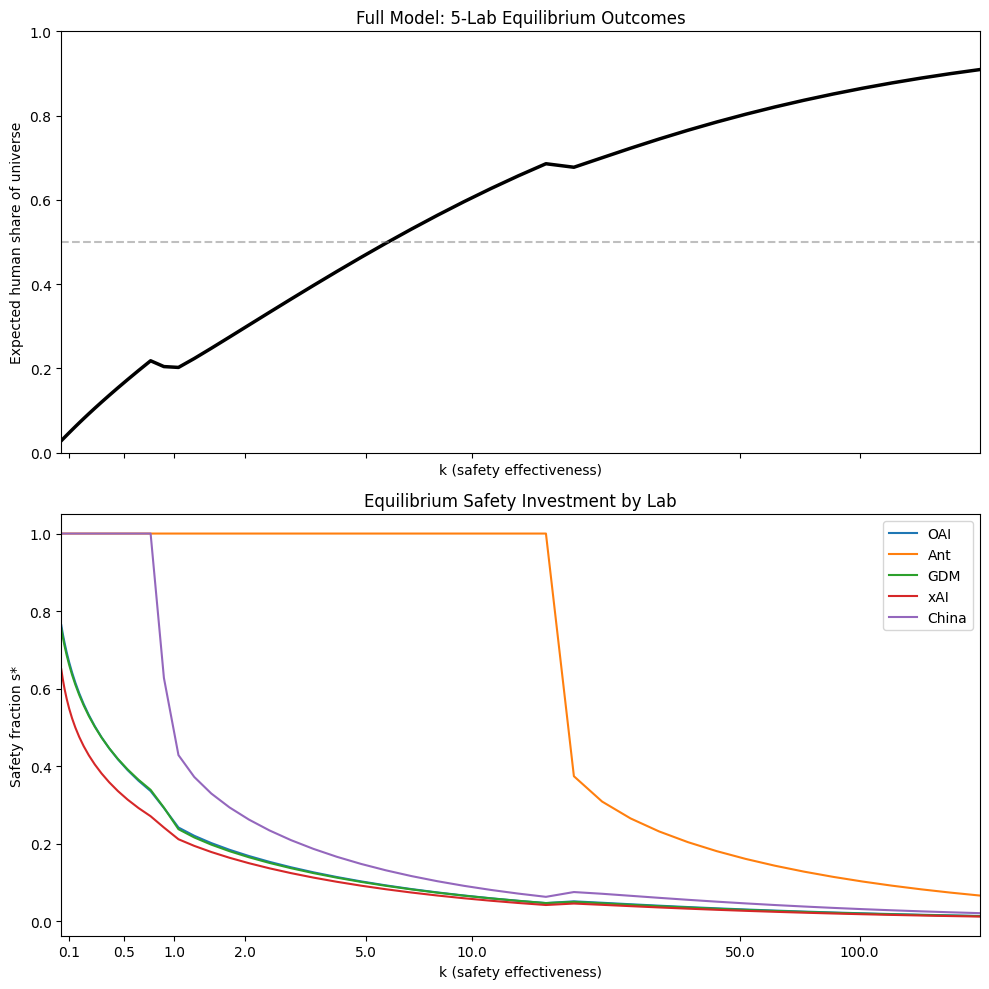

In [4]:
data = full_model.default_outcomes_vs_k()
plots_v2.plot_full_model_vs_k(data);

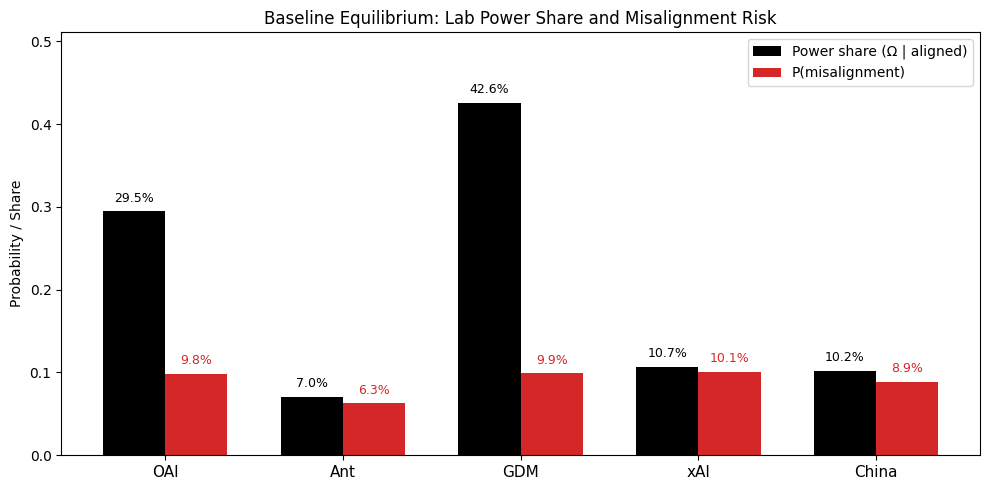

In [5]:
summary = full_model.default_lab_summary()
plots_v2.plot_lab_summary(summary);

### Interventions

How do various interventions change the expected human share relative to the baseline?

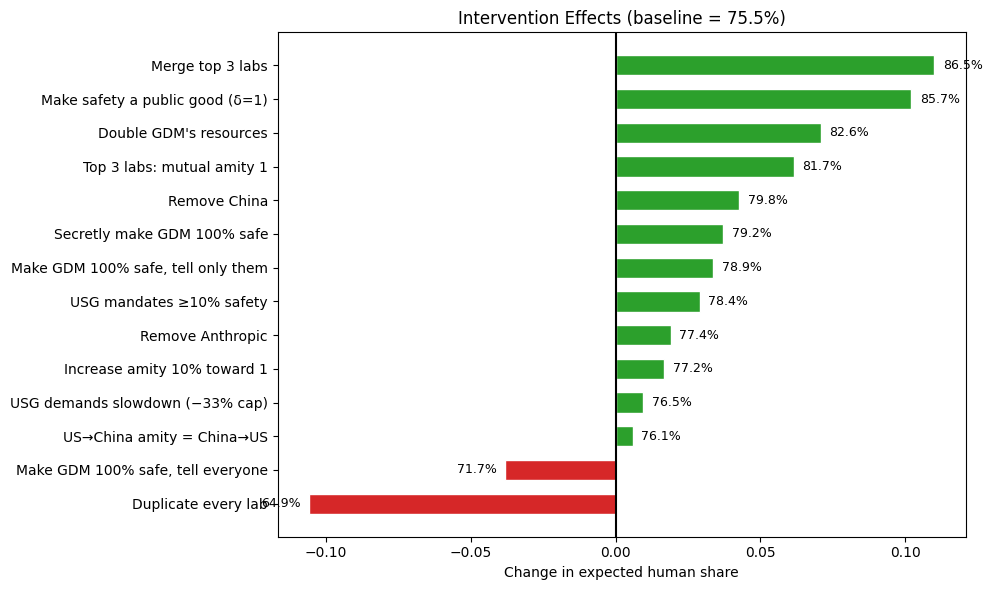

In [6]:
results = interventions.compute_interventions()
plots_v2.plot_interventions(results);

### Sensitivity Analysis

We sample 500 parameter vectors from triangular priors and compute the Nash equilibrium for each. Each subplot shows the conditional median expected human share as a function of one parameter, with all other parameters marginalized.

Parameters varied:
- $w$ (winner-take-all): [1, 5], mode 2
- $\delta$ (public good): [0, 0.75], mode 0.5
- $\rho$ (correlation): [0, 1], mode 0.5
- $z$ (misaligned power): [0.5, 1], mode 1
- China's resource share: [0.05, 0.25], mode 0.15
- Average amity (off-diagonal): scaled from 0.67× to 2× default

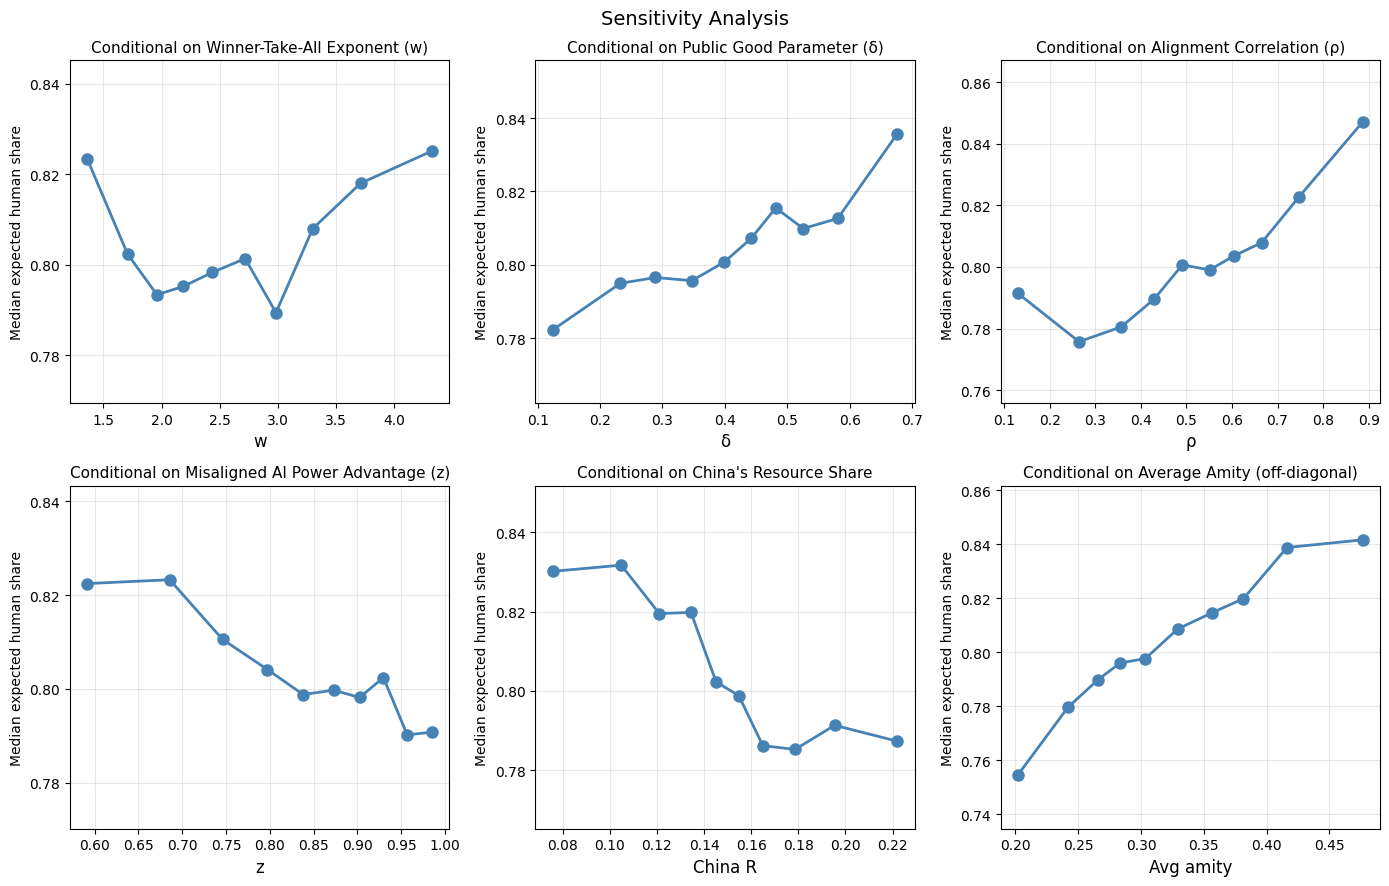

In [7]:
sens_data = sensitivity.run_sensitivity(n_samples=500)
plots_v2.plot_sensitivity(sens_data);

## Appendix A: Parameter Choices

See `docs/parameters.md` for full reasoning behind resource vector $R$ and amity matrix $A$ estimates, including sources on compute infrastructure, frontier model standing, and lab culture.

## Appendix B: When Is Computing Nash Equilibrium Easy?

See `docs/closed_forms.md` for detailed derivations. Key results:

| Case | Closed form? |
|------|:-----------:|
| Symmetric, α=1, any n, any w | Yes — quadratic in p |
| + public good δ (symmetric, α=1) | Same — δ drops out |
| General α | No — transcendental |
| Asymmetric resources (α=1) | In principle, degree 4+ |
| Correlated alignment | No — requires numerical CDF |

## Appendix C: Why Gaussian Copula?

We use a Gaussian copula with equicorrelation $\rho$ to model correlated alignment outcomes. This choice is motivated by:

1. **Mathematical tractability**: The equicorrelation structure allows dimension reduction via $X_i = \sqrt{\rho} Z + \sqrt{1-\rho} \varepsilon_i$, reducing the $n$-dimensional CDF to 1D quadrature. This makes Nash equilibrium computation fast even with correlation.

2. **Single-parameter simplicity**: The equicorrelation assumption means one parameter $\rho$ captures the strength of shared alignment difficulty.

3. **No tail dependence**: The Gaussian copula has no tail dependence, meaning extreme failures aren't more correlated than moderate ones. This is a modeling assumption — a Clayton copula (lower tail dependence) would model "correlated catastrophic failures" where if alignment is hard for one lab, it's hard for everyone. A t-copula would add symmetric tail dependence.

The key question is whether copula choice changes *which parameters matter most* or just shifts survival probability uniformly. Based on the structure of the model, we expect the copula primarily affects the level of joint survival rather than the relative importance of parameters, because the copula only enters through joint survival probability, not through the strategic interaction (which depends on marginal probabilities). A detailed numerical comparison is planned in `plans/copula.md`.